In [1]:
import os

# Create folders
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Create sample data
data = """Wavelength_nm,Intensity_300K,Intensity_350K,Intensity_400K
400,120,110,95
410,145,130,112
420,189,170,150
430,256,230,198
440,312,285,245
450,398,360,310
460,489,445,380
470,567,512,438
480,623,570,490
490,589,535,458
500,512,465,398
510,445,402,345
520,378,342,290
530,289,261,220
540,198,179,150
550,145,131,110"""

with open('data/sample_spectra.csv', 'w') as f:
    f.write(data)

print("✅ Folders and data file created successfully!")

✅ Folders and data file created successfully!


In [5]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", 
                      "pandas", "numpy", "matplotlib", 
                      "scipy", "seaborn", "plotly"])

0

In [6]:
import sys
print(sys.executable)

C:\Users\Pratibha Thakur\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('data/sample_spectra.csv')

print("✅ Data Loaded Successfully!")
print(f"\nShape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic Statistics:")
print(df.describe())

✅ Data Loaded Successfully!

Shape: (16, 4)

First 5 rows:
   Wavelength_nm  Intensity_300K  Intensity_350K  Intensity_400K
0            400             120             110              95
1            410             145             130             112
2            420             189             170             150
3            430             256             230             198
4            440             312             285             245

Basic Statistics:
       Wavelength_nm  Intensity_300K  Intensity_350K  Intensity_400K
count      16.000000        16.00000       16.000000       16.000000
mean      475.000000       353.43750      320.437500      274.312500
std        47.609523       170.52936      155.381667      133.185945
min       400.000000       120.00000      110.000000       95.000000
25%       437.500000       195.75000      176.750000      150.000000
50%       475.000000       345.00000      313.500000      267.500000
75%       512.500000       494.75000      450.000

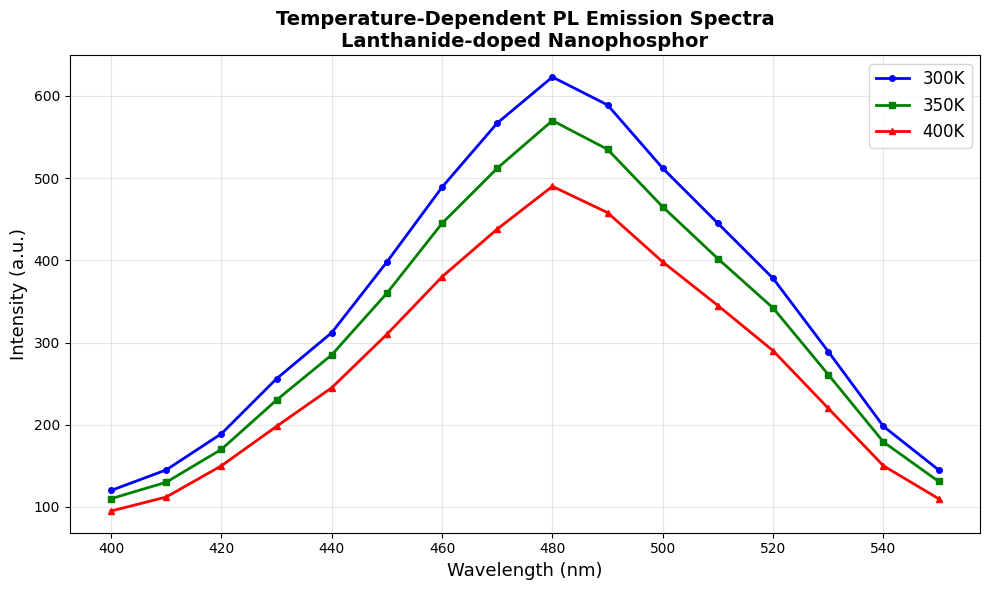

✅ Plot saved to outputs/emission_spectra.png


In [10]:
import matplotlib.pyplot as plt

# Plot Emission Spectra
plt.figure(figsize=(10, 6))

plt.plot(df['Wavelength_nm'], df['Intensity_300K'], 
         'b-o', label='300K', linewidth=2, markersize=4)
plt.plot(df['Wavelength_nm'], df['Intensity_350K'], 
         'g-s', label='350K', linewidth=2, markersize=4)
plt.plot(df['Wavelength_nm'], df['Intensity_400K'], 
         'r-^', label='400K', linewidth=2, markersize=4)

plt.xlabel('Wavelength (nm)', fontsize=13)
plt.ylabel('Intensity (a.u.)', fontsize=13)
plt.title('Temperature-Dependent PL Emission Spectra\nLanthanide-doped Nanophosphor', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('outputs/emission_spectra.png', dpi=300)
plt.show()

print("✅ Plot saved to outputs/emission_spectra.png")

In [12]:
from scipy.signal import find_peaks

# Find peaks
peaks_300, _ = find_peaks(df['Intensity_300K'], height=300)
peaks_350, _ = find_peaks(df['Intensity_350K'], height=300)
peaks_400, _ = find_peaks(df['Intensity_400K'], height=300)

print("=" * 45)
print("       PEAK DETECTION ANALYSIS")
print("=" * 45)
print(f"\n🔵 300K Peak: "
      f"{df['Wavelength_nm'].iloc[peaks_300].values} nm "
      f"| Intensity: {df['Intensity_300K'].iloc[peaks_300].values}")
print(f"\n🟢 350K Peak: "
      f"{df['Wavelength_nm'].iloc[peaks_350].values} nm "
      f"| Intensity: {df['Intensity_350K'].iloc[peaks_350].values}")
print(f"\n🔴 400K Peak: "
      f"{df['Wavelength_nm'].iloc[peaks_400].values} nm "
      f"| Intensity: {df['Intensity_400K'].iloc[peaks_400].values}")
print("\n" + "=" * 45)
print("✅ Peak detection complete!")

       PEAK DETECTION ANALYSIS

🔵 300K Peak: [480] nm | Intensity: [623]

🟢 350K Peak: [480] nm | Intensity: [570]

🔴 400K Peak: [480] nm | Intensity: [490]

✅ Peak detection complete!


     THERMAL QUENCHING ANALYSIS

Peak Intensity at 300K: 623
Peak Intensity at 350K: 570
Peak Intensity at 400K: 490

Quenching at 350K: 8.5%
Quenching at 400K: 21.3%


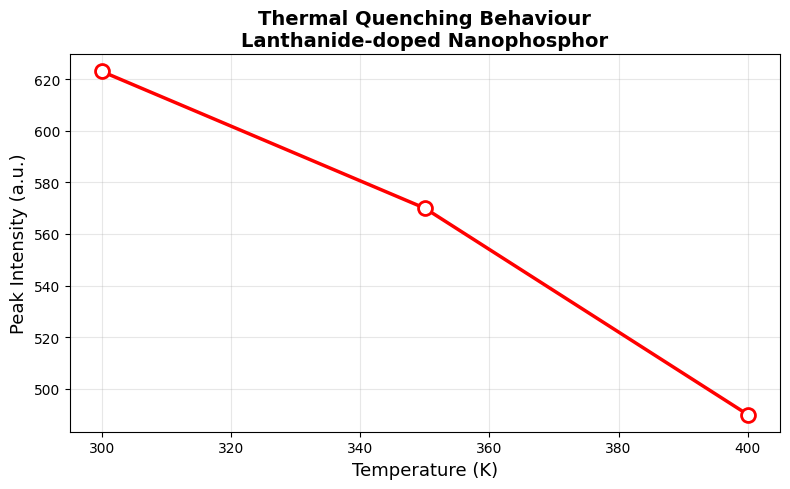


✅ Thermal quenching plot saved!


In [13]:
# Thermal Quenching Analysis
temperatures = [300, 350, 400]
max_intensities = [
    df['Intensity_300K'].max(),
    df['Intensity_350K'].max(),
    df['Intensity_400K'].max()
]

# Calculate quenching percentage
quench_350 = ((max_intensities[0] - max_intensities[1]) 
               / max_intensities[0]) * 100
quench_400 = ((max_intensities[0] - max_intensities[2]) 
               / max_intensities[0]) * 100

print("=" * 45)
print("     THERMAL QUENCHING ANALYSIS")
print("=" * 45)
print(f"\nPeak Intensity at 300K: {max_intensities[0]}")
print(f"Peak Intensity at 350K: {max_intensities[1]}")
print(f"Peak Intensity at 400K: {max_intensities[2]}")
print(f"\nQuenching at 350K: {quench_350:.1f}%")
print(f"Quenching at 400K: {quench_400:.1f}%")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(temperatures, max_intensities, 
         'ro-', linewidth=2.5, markersize=10,
         markerfacecolor='white', markeredgewidth=2)

plt.xlabel('Temperature (K)', fontsize=13)
plt.ylabel('Peak Intensity (a.u.)', fontsize=13)
plt.title('Thermal Quenching Behaviour\nLanthanide-doped Nanophosphor', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/thermal_quenching.png', dpi=300)
plt.show()

print("\n✅ Thermal quenching plot saved!")

In [16]:
# Final Summary
print("=" * 50)
print("     PROJECT SUMMARY REPORT")
print("=" * 50)
print(f"\n📊 Dataset: {df.shape[0]} wavelength points")
print(f"📍 Wavelength Range: "
      f"{df['Wavelength_nm'].min()}–{df['Wavelength_nm'].max()} nm")
print(f"\n🔵 300K → Peak: 480nm | Max Intensity: 623")
print(f"🟢 350K → Peak: 480nm | Max Intensity: 570")
print(f"🔴 400K → Peak: 480nm | Max Intensity: 490")
print(f"\n📉 Thermal Quenching:")
print(f"   300K → 350K : {quench_350:.1f}% reduction")
print(f"   300K → 400K : {quench_400:.1f}% reduction")
print(f"\n💡 Conclusion:")
print(f"   Peak position stable at 480nm across all")
print(f"   temperatures — confirms good thermal")
print(f"   stability of the nanophosphor material.")
print(f"\n✅ Plots saved in: outputs/")
print(f"   → emission_spectra.png")
print(f"   → thermal_quenching.png")
print("=" * 50)
print("\n🎓 Analysis by: Dr. Pratibha K Thakur")
print("   PhD Physics | MSc Data Science (Pursuing)")
print("=" * 50)

     PROJECT SUMMARY REPORT

📊 Dataset: 16 wavelength points
📍 Wavelength Range: 400–550 nm

🔵 300K → Peak: 480nm | Max Intensity: 623
🟢 350K → Peak: 480nm | Max Intensity: 570
🔴 400K → Peak: 480nm | Max Intensity: 490

📉 Thermal Quenching:
   300K → 350K : 8.5% reduction
   300K → 400K : 21.3% reduction

💡 Conclusion:
   Peak position stable at 480nm across all
   temperatures — confirms good thermal
   stability of the nanophosphor material.

✅ Plots saved in: outputs/
   → emission_spectra.png
   → thermal_quenching.png

🎓 Analysis by: Dr. Pratibha K Thakur
   PhD Physics | MSc Data Science (Pursuing)
